In [48]:
# 📦 Librerías base
import pandas as pd
import numpy as np

# 📊 Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 🧰 Utilidades
import os
import time
from datetime import datetime

In [49]:
archivo=("C:\\Users\\Admin\\Documents\\GitHub\\VJaroszewski-econ\\codigos\\Codigos_resNet\\Financiamiento del tesoro\\calculos.xlsx")
df = pd.read_excel(archivo, sheet_name="Hoja3")


In [67]:
df_03 = df[df['fecha'].between('2003-01-01', '2026-12-31')].copy()
df_03['fecha'] = pd.to_datetime(df_03['fecha'])

df_03_base = (df_03
    .groupby(df_03['fecha'].dt.to_period('M'))
    .last()
    .reset_index(drop=True)
    [['fecha', 'base monetaria saldo']])
df_03_base

,fecha,base monetaria saldo
0,2003-01-31,3.730564e+04
1,2003-02-28,3.797756e+04
2,2003-03-28,3.834137e+04
3,2003-04-30,3.914867e+04
4,2003-05-30,4.083983e+04
...,...,...
274,2025-11-28,4.092661e+07
275,2025-12-30,4.295696e+07
276,2026-01-30,4.281234e+07
277,2026-02-27,4.098670e+07


In [79]:
ult=df_03_base['base monetaria saldo'].iloc[0]
prim=df_03_base['base monetaria saldo'].iloc[-1]
np.log(prim)-np.log(ult)

np.float64(6.969319547292724)

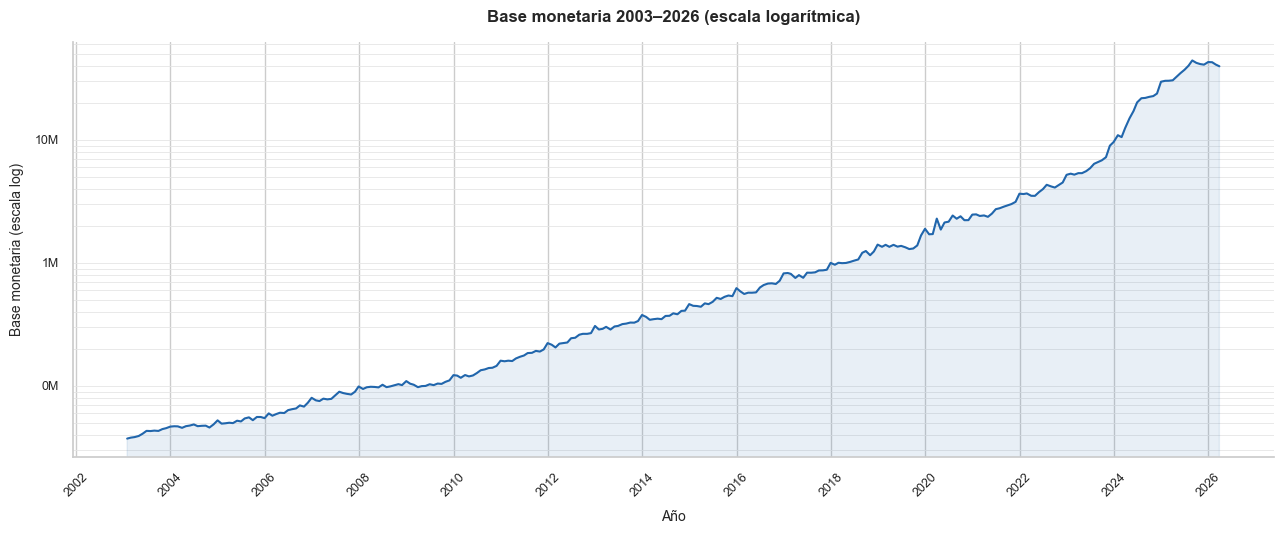

In [68]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np

# Reemplazar con tu DataFrame
# df_03_base debe tener columnas 'fecha' y 'base monetaria saldo'

fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(df_03_base['fecha'], df_03_base['base monetaria saldo'],
        color='#2166ac', linewidth=1.5)

ax.fill_between(df_03_base['fecha'], df_03_base['base monetaria saldo'],
                alpha=0.1, color='#2166ac')

# Escala logarítmica
ax.set_yscale('log')

# Formato del eje Y en millones/billones legibles
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x/1e9:.0f}B' if x >= 1e9 else f'{x/1e6:.0f}M'
))

# Eje X por años
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_tick_params(rotation=45, labelsize=9)
ax.yaxis.set_tick_params(labelsize=9)

# Estilo
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.yaxis.grid(True, color='#e5e5e5', linewidth=0.6, which='both')
ax.set_axisbelow(True)

ax.set_xlabel('Año', fontsize=10, labelpad=8)
ax.set_ylabel('Base monetaria (escala log)', fontsize=10, labelpad=8)
ax.set_title('Base monetaria 2003–2026 (escala logarítmica)',
             fontsize=12, fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('base_monetaria_log.png', dpi=180, bbox_inches='tight')
plt.show()

In [69]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_03_base['fecha'],
    y=df_03_base['base monetaria saldo'],
    mode='lines',
    line=dict(color='#2166ac', width=1.5),
    fill='tozeroy',
    fillcolor='rgba(33, 102, 172, 0.1)',
    name='Base monetaria'
))

fig.update_layout(
    title=dict(
        text='Base monetaria 2003–2026 (escala logarítmica)',
        font=dict(size=14)
    ),
    xaxis=dict(
        title='Año',
        showgrid=False,
        tickangle=45,
    ),
    yaxis=dict(
        title='Base monetaria (escala log)',
        type='log',
        tickformat='.3s',
        gridcolor='#e5e5e5',
        gridwidth=0.6,
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=500,
    width=900,
)

fig.update_xaxes(showline=True, linecolor='#cccccc')
fig.update_yaxes(showline=True, linecolor='#cccccc')

fig.show()

In [50]:
df_23 = df[df['fecha'].between('2023-01-01', '2023-12-31')].copy()
df_23['fecha'] = pd.to_datetime(df_23['fecha'])

df_23_base = (df_23
    .groupby(df_23['fecha'].dt.to_period('M'))
    .last()
    .reset_index(drop=True)
    [['fecha', 'base monetaria saldo']])
df_23_base

,fecha,base monetaria saldo
0,2023-01-31,5316722.0
1,2023-02-28,5219956.0
2,2023-03-31,5369482.0
3,2023-04-28,5366598.0
4,2023-05-31,5576415.0
5,2023-06-30,5885739.0
6,2023-07-31,6392700.0
7,2023-08-31,6621931.0
8,2023-09-29,6828209.0
9,2023-10-31,7237385.0


In [51]:
variacion_abs = df_23['var base mone'].sum()
variacion_pct = variacion_abs / df_23['base monetaria saldo'].iloc[0]
print(f"La base monetaria se amplió ${variacion_abs:,.0f} millones ({variacion_pct:.1%}) durante 2023.")

La base monetaria se amplió $4,404,240 millones (84.7%) durante 2023.


In [52]:
print(df.columns.tolist())

['fecha', 'var base mone', 'Compra neta devisas priv', 'Compra neta devisas tesoro', 'adelantos transitorios', 'transf utilidades', 'resto tesoro', 'pases', 'LELIQ y NOTALIQ', 'Redescuentos y Adelantos', 'intereses y remuneracion', 'LEBAC y NOBAC', 'Rescate de Cuasimonedas', 'Operaciones con LEFI', 'Otros', 'base monetaria saldo']


In [53]:
df_23['compra neta de divisas']=df_23['Compra neta devisas priv']+df_23['Compra neta devisas tesoro']
compra_usd=df_23['compra neta de divisas'].sum()
Var_base_compraUsd=compra_usd/variacion_abs
print(f"la variacion de la base monetaria se explica por la compra neta de divisas en un {Var_base_compraUsd:.1%}")
print()
Transf_tesoro=df_23['adelantos transitorios'].sum()+(df_23['transf utilidades'].sum())
Var_base_adelantos=Transf_tesoro/variacion_abs
print(f"la variacion de la base monetaria se explica por las transferencias al tesoro en un {Var_base_adelantos:.1%}")

la variacion de la base monetaria se explica por la compra neta de divisas en un 10.9%

la variacion de la base monetaria se explica por las transferencias al tesoro en un 38.6%


In [65]:
df_23_base

,fecha,base monetaria saldo,mes
0,2023-01-31,5316722.0,2023-01
1,2023-02-28,5219956.0,2023-02
2,2023-03-31,5369482.0,2023-03
3,2023-04-28,5366598.0,2023-04
4,2023-05-31,5576415.0,2023-05
5,2023-06-30,5885739.0,2023-06
6,2023-07-31,6392700.0,2023-07
7,2023-08-31,6621931.0,2023-08
8,2023-09-29,6828209.0,2023-09
9,2023-10-31,7237385.0,2023-10


In [54]:
df_pib = pd.read_excel(archivo, sheet_name="Hoja4")
df_pib['fecha'] = pd.to_datetime(df_pib['fecha'])
df_pib = df_pib.groupby(df_pib['fecha'].dt.to_period('M')).last().reset_index(drop=True)
df_pib['fecha'] = df_pib['fecha'].dt.to_period('M').dt.to_timestamp('M')
df_pib['mes'] = df_pib['fecha'].dt.to_period('M')

df_23_base['mes'] = df_23_base['fecha'].dt.to_period('M')

df_pib = df_pib.merge(df_23_base[['mes', 'base monetaria saldo']], on='mes', how='left')


df_pib['base_monetaria_pct_pib'] = df_pib['base monetaria saldo'] / df_pib['PIB'] 
df_pib

,fecha,PIB,SP primario,SP fiscal,Primario PIB,Financiero PIB,Financiamiento del BCRA,transf bcra / pib,tc,mes,base monetaria saldo,base_monetaria_pct_pib
0,2023-01-31,1.207196e+08,-203938.0,-537969.0,-0.001689,-0.004456,0,0.000000,186,2023-01,5316722.0,0.044042
1,2023-02-28,1.207196e+08,-228134.0,-485590.0,-0.001890,-0.004022,0,0.000000,197,2023-02,5219956.0,0.043240
2,2023-03-31,1.207196e+08,-257855.0,-388005.0,-0.002136,-0.003214,130000,0.001077,208,2023-03,5369482.0,0.044479
3,2023-04-30,1.592159e+08,-331372.0,-407388.0,-0.002081,-0.002559,100000,0.000628,222,2023-04,5366598.0,0.033706
4,2023-05-31,1.592159e+08,-247650.0,-631071.0,-0.001555,-0.003964,440000,0.002764,239,2023-05,5576415.0,0.035024
5,2023-06-30,1.592159e+08,-611743.0,-708603.0,-0.003842,-0.004451,688000,0.004321,256,2023-06,5885739.0,0.036967
6,2023-07-31,2.065164e+08,-334366.0,-754243.0,-0.001619,-0.003652,590000,0.002857,275,2023-07,6392700.0,0.030955
7,2023-08-31,2.065164e+08,-36964.0,-384504.0,-0.000179,-0.001862,-250000,-0.001211,350,2023-08,6621931.0,0.032065
8,2023-09-30,2.065164e+08,-380473.4,-511532.7,-0.001842,-0.002477,0,0.000000,350,2023-09,6828209.0,0.033064
9,2023-10-31,2.831812e+08,-330338.0,-454248.0,-0.001167,-0.001604,0,0.000000,350,2023-10,7237385.0,0.025557


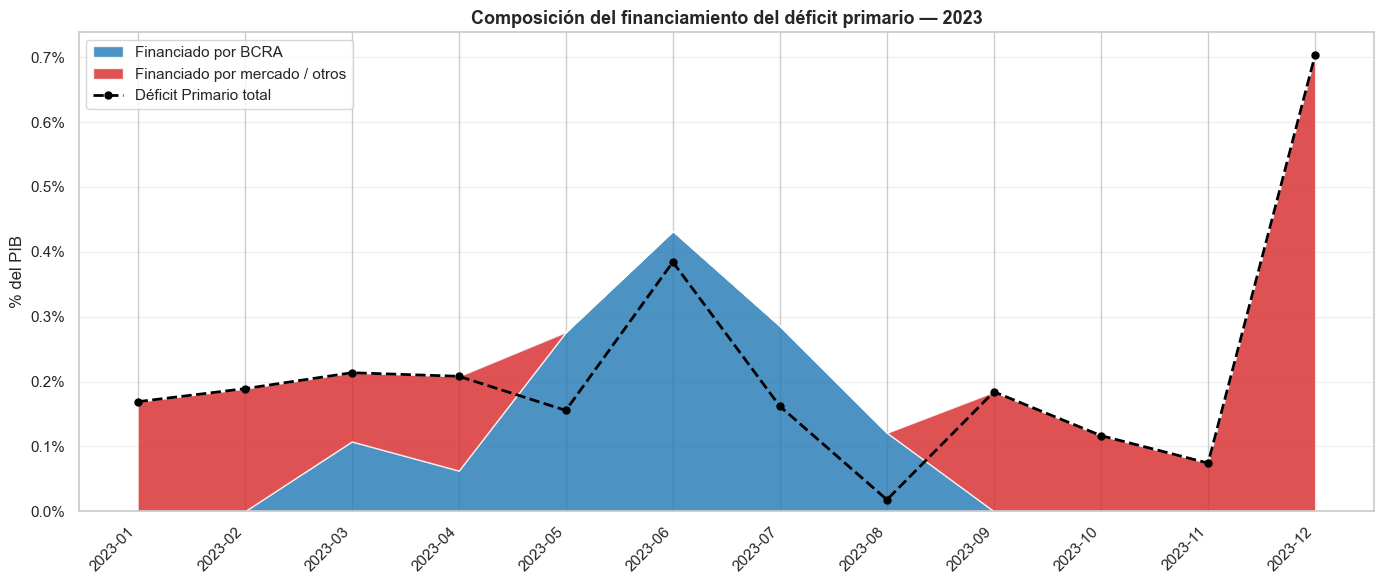

In [55]:
fig, ax = plt.subplots(figsize=(14, 6))

meses = df_pib['mes'].astype(str)
x = list(range(len(meses)))

deficit = df_pib['Primario PIB'].abs() * 100
cubierto = df_pib['transf bcra / pib'].abs() * 100
no_cubierto = (deficit - cubierto).clip(lower=0)

ax.stackplot(x,
             cubierto,
             no_cubierto,
             labels=['Financiado por BCRA', 'Financiado por mercado / otros'],
             colors=['#1f77b4', '#d62728'],
             alpha=0.8)

ax.plot(x, deficit,
        color='black', linewidth=2, linestyle='--',
        marker='o', markersize=5, label='Déficit Primario total')

ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=45, ha='right')
ax.set_ylabel("% del PIB")
ax.set_title("Composición del financiamiento del déficit primario — 2023", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

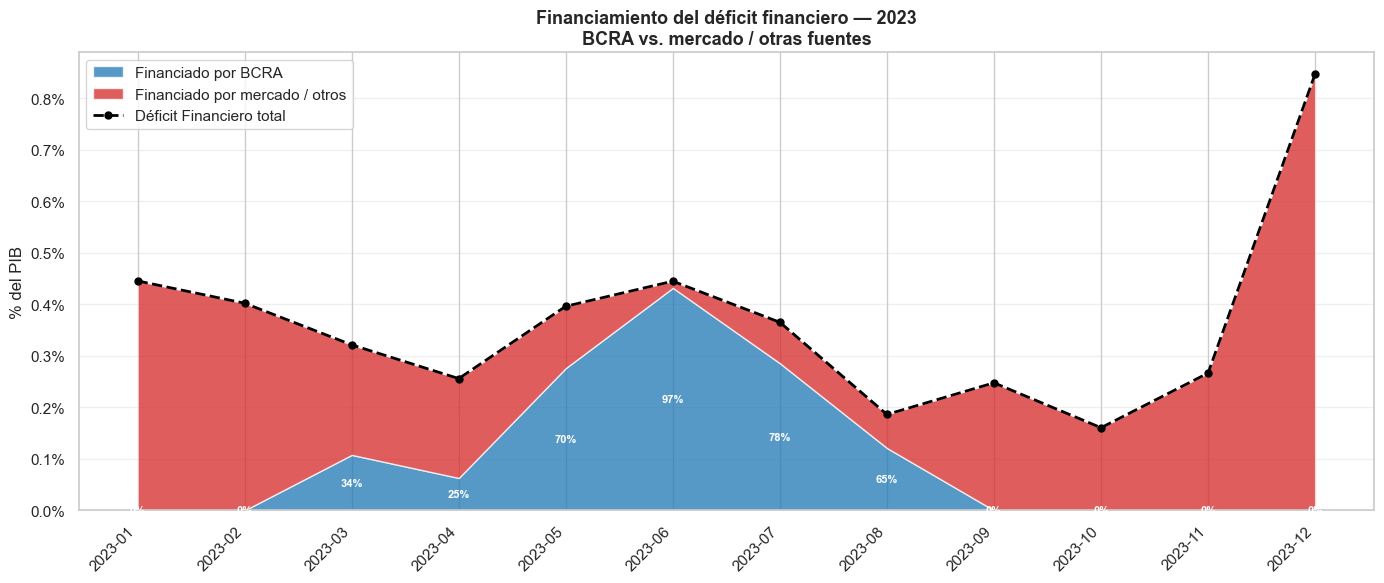

In [56]:
fig, ax = plt.subplots(figsize=(14, 6))

meses = df_pib['mes'].astype(str)
x = list(range(len(meses)))

deficit    = df_pib['Financiero PIB'].abs() * 100
cubierto   = df_pib['transf bcra / pib'].abs() * 100
no_cubierto = (deficit - cubierto).clip(lower=0)

ax.stackplot(x,
             cubierto,
             no_cubierto,
             labels=['Financiado por BCRA', 'Financiado por mercado / otros'],
             colors=['#1f77b4', '#d62728'],
             alpha=0.75)

ax.plot(x, deficit,
        color='black', linewidth=2, linestyle='--',
        marker='o', markersize=5, label='Déficit Financiero total')

# Etiquetas de % cubierto por BCRA en cada barra
for i, (cub, def_) in enumerate(zip(cubierto, deficit)):
    pct = cub / def_ * 100 if def_ > 0 else 0
    ax.annotate(f"{pct:.0f}%",
                xy=(i, cub / 2),
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(meses, rotation=45, ha='right')
ax.set_ylabel("% del PIB")
ax.set_title("Financiamiento del déficit financiero — 2023\nBCRA vs. mercado / otras fuentes",
             fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [57]:
df_pib['base_monetaria_pct_pib'].mean()

np.float64(0.0353930905638793)

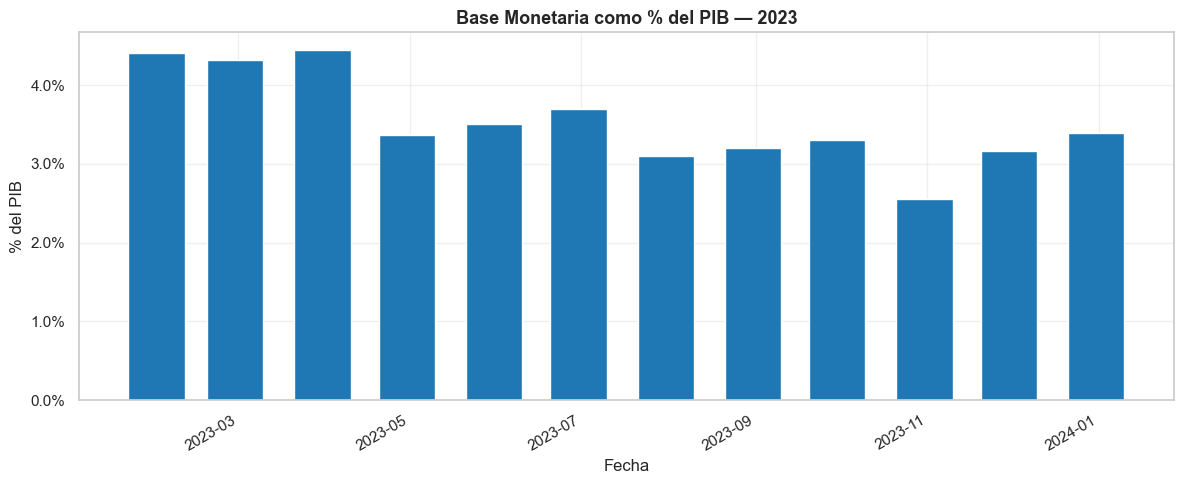

In [58]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_pib['fecha'], df_pib['base_monetaria_pct_pib'] * 100,
       color="#1f77b4", width=20, edgecolor="white")

ax.set_xlabel("Fecha")
ax.set_ylabel("% del PIB")
ax.set_title("Base Monetaria como % del PIB — 2023", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.grid(True, alpha=0.3)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [59]:
df['fecha'] = pd.to_datetime(df['fecha'])

dfs_base = {}
for year in range(2003, 2026):
    df_year = df[df['fecha'].dt.year == year].copy()
    dfs_base[year] = (df_year
        .groupby(df_year['fecha'].dt.to_period('M'))
        .last()
        .reset_index(drop=True)
        [['fecha', 'base monetaria saldo']])


In [60]:
for year in range(2003, 2026):
    df_year = df[df['fecha'].dt.year == year].copy()
    if df_year.empty:
        continue
    variacion_abs = df_year['var base mone'].sum()
    variacion_pct = variacion_abs / df_year['base monetaria saldo'].iloc[0]
    print(f"La base monetaria se amplió ${variacion_abs:,.0f} millones ({variacion_pct:.1%}) durante {year}.")


La base monetaria se amplió $17,240 millones (46.4%) durante 2003.
La base monetaria se amplió $6,086 millones (13.0%) durante 2004.
La base monetaria se amplió $2,233 millones (4.3%) durante 2005.
La base monetaria se amplió $25,356 millones (46.2%) durante 2006.
La base monetaria se amplió $18,912 millones (23.6%) durante 2007.
La base monetaria se amplió $10,470 millones (10.5%) durante 2008.
La base monetaria se amplió $12,901 millones (11.8%) durante 2009.
La base monetaria se amplió $38,058 millones (30.7%) durante 2010.
La base monetaria se amplió $62,514 millones (38.4%) durante 2011.
La base monetaria se amplió $84,430 millones (38.0%) durante 2012.
La base monetaria se amplió $69,845 millones (22.9%) durante 2013.
La base monetaria se amplió $85,368 millones (22.6%) durante 2014.
La base monetaria se amplió $161,325 millones (34.6%) durante 2015.
La base monetaria se amplió $197,775 millones (31.9%) durante 2016.
La base monetaria se amplió $179,449 millones (21.0%) durante 2

In [61]:
Var_base_compraUsd = {}
for year in range(2003, 2027):
    df_year = df[df['fecha'].dt.year == year].copy()
    if df_year.empty:
        continue
    df_year['compra neta de divisas'] = df_year['Compra neta devisas priv'] + df_year['Compra neta devisas tesoro']
    compra_usd = df_year['compra neta de divisas'].sum()
    variacion_abs = df_year['var base mone'].sum()
    Var_base_compraUsd[year] = compra_usd / variacion_abs

Var_base_compraUsd


{2003: np.float64(0.5258224288850197),
 2004: np.float64(1.4022129472601104),
 2005: np.float64(11.25871559635101),
 2006: np.float64(1.4687864738503964),
 2007: np.float64(1.4059509706899262),
 2008: np.float64(-1.67000061137679),
 2009: np.float64(-0.2333948085002213),
 2010: np.float64(1.184654785529624),
 2011: np.float64(0.15307447808074334),
 2012: np.float64(0.3225877639102175),
 2013: np.float64(-0.2346059928600632),
 2014: np.float64(0.9589125620803086),
 2015: np.float64(-0.4305760448028504),
 2016: np.float64(1.0573619344058989),
 2017: np.float64(1.4837423804861896),
 2018: np.float64(-1.0578477833515827),
 2019: np.float64(-0.5797172755875476),
 2020: np.float64(-0.8231046261909029),
 2021: np.float64(0.45613027992185173),
 2022: np.float64(0.8028256024220115),
 2023: np.float64(0.10929688246980408),
 2024: np.float64(0.09433202669334391),
 2025: np.float64(-0.27745014037989507),
 2026: np.float64(-0.16548836813405504)}

In [62]:
var_for_transf_tesoro={}
for year in range (2003,2027):
    df_year=df[df['fecha'].dt.year== year].copy()
    if df_year.empty:
        continue
    var_base=df_year['var base mone'].sum()
    trasf_tesoro=df_year['adelantos transitorios'].sum()+df_year['transf utilidades'].sum()
    var_for_transf=trasf_tesoro/var_base
    var_for_transf_tesoro[year]=var_for_transf
    print(f"la variacion de la base motenetaria se explica en un {var_for_transf:.1%} por las transferencias la tesoro en el año {year}")

la variacion de la base motenetaria se explica en un 43.7% por las transferencias la tesoro en el año 2003
la variacion de la base motenetaria se explica en un 114.0% por las transferencias la tesoro en el año 2004
la variacion de la base motenetaria se explica en un 120.4% por las transferencias la tesoro en el año 2005
la variacion de la base motenetaria se explica en un 13.7% por las transferencias la tesoro en el año 2006
la variacion de la base motenetaria se explica en un 21.9% por las transferencias la tesoro en el año 2007
la variacion de la base motenetaria se explica en un 92.2% por las transferencias la tesoro en el año 2008
la variacion de la base motenetaria se explica en un 111.6% por las transferencias la tesoro en el año 2009
la variacion de la base motenetaria se explica en un 78.4% por las transferencias la tesoro en el año 2010
la variacion de la base motenetaria se explica en un 47.4% por las transferencias la tesoro en el año 2011
la variacion de la base motenetari

AttributeError: 'dict' object has no attribute 'index'

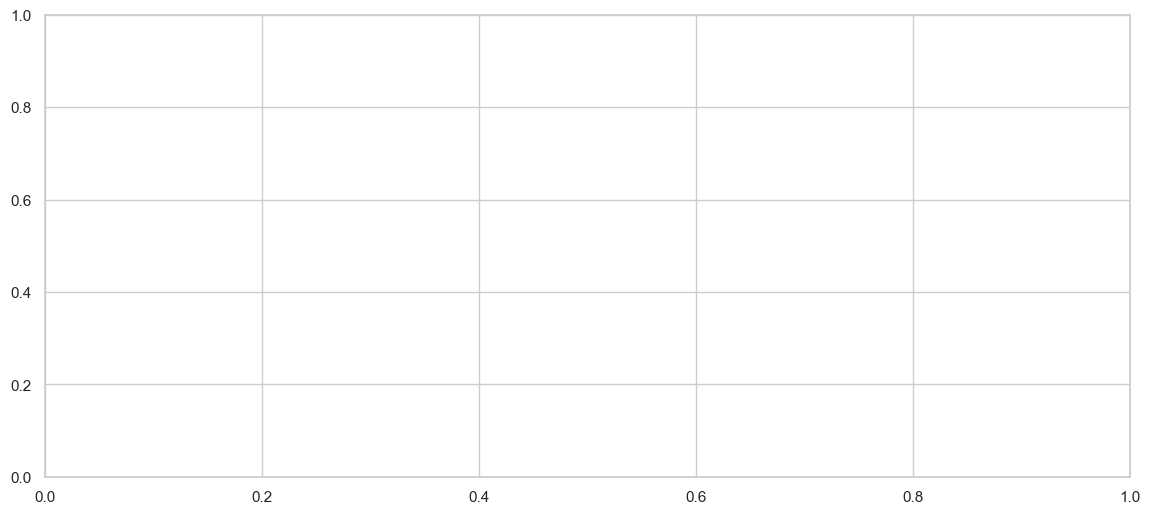

In [63]:
fig, ax = plt.subplots(figsize=(14, 6))

years = var_for_transf_tesoro.index.astype(int)
values = var_for_transf_tesoro.values * 100
colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]

bars = ax.bar(years, values, color=colors, edgecolor='white', linewidth=1.2)

ax.axhline(0, color='black', linewidth=0.8)

for bar, val in zip(bars, values):
    va = 'bottom' if val >= 0 else 'top'
    offset = 1.5 if val >= 0 else -1.5
    ax.text(bar.get_x() + bar.get_width() / 2, val + offset,
            f"{val:.1f}%", ha='center', va=va, fontsize=7.5)

ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right')
ax.set_ylabel("% de la variación de la base")
ax.set_title("Contribución de las transferencias al Tesoro\na la variación de la base monetaria",
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
var_for_transf_tesoro = pd.Series(var_for_transf_tesoro.copy())
import plotly.graph_objects as go

years = var_for_transf_tesoro.index.astype(str).tolist()
values = var_for_transf_tesoro.values * 100
colors = ['#1f77b4' if v >= 0 else '#d62728' for v in values]

fig = go.Figure()

fig.add_trace(go.Bar(
    x=years,
    y=values,
    marker_color=colors,
    marker_line_color='white',
    marker_line_width=1.5,
    text=[f"{v:.1f}%" for v in values],
    textposition='outside'
))

fig.update_layout(
    title="Contribución de las transferencias al Tesoro a la variación de la base monetaria",
    xaxis_title="Año",
    yaxis_title="% de la variación de la base",
    yaxis_ticksuffix="%",
    plot_bgcolor='white',
    height=500,
    width=900,
    shapes=[dict(
        type='line',
        x0=-0.5, x1=len(years) - 0.5,
        y0=0, y1=0,
        line=dict(color='black', width=1)
    )]
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=True, gridcolor='lightgrey', gridwidth=0.5)

fig.show()